In [1]:
import warnings
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/nigeria_dataset.csv")
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (5000, 9)


,N,P,K,temperature,humidity,ph,rainfall,soil,crop_label
0,40,27,45,21.66,94.79,5.89,112.43,sandy loam,guinea_corn
1,120,7,47,24.25,83.04,6.65,54.77,loamy clay,pepper
2,102,11,47,27.99,92.78,6.50,27.15,sandy loam,tomatoes
3,5,25,6,30.72,94.01,6.01,106.81,loamy,orange
4,36,43,21,28.36,84.86,7.14,52.93,loamy,yam


### EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            5000 non-null   int64  
 1   P            5000 non-null   int64  
 2   K            5000 non-null   int64  
 3   temperature  5000 non-null   float64
 4   humidity     5000 non-null   float64
 5   ph           5000 non-null   float64
 6   rainfall     5000 non-null   float64
 7   soil         5000 non-null   str    
 8   crop_label   5000 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 351.7 KB


In [4]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
soil           0
crop_label     0
dtype: int64


In [5]:
display(df.describe())

,N,P,K,temperature,humidity,ph,rainfall
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.226400,40.841600,36.242000,23.772518,68.377278,6.559738,91.334658
std,34.969383,22.755133,21.174662,4.563245,28.676976,0.650217,55.271848
min,0.000000,5.000000,5.000000,10.010000,14.260000,5.010000,20.210000
25%,22.000000,20.000000,19.000000,19.867500,59.250000,6.100000,56.020000
50%,39.000000,41.000000,36.000000,24.365000,83.120000,6.500000,80.110000
75%,84.000000,60.000000,49.000000,27.445000,90.020000,6.950000,108.480000
max,120.000000,80.000000,85.000000,34.950000,95.000000,8.870000,298.560000


Setting target columns and seperating the label from the feature.

In [6]:
target_col = (
    "crop_label" if "crop_label" in df.columns else df.columns[-1]
)

X = df.drop(columns=[target_col])
y = df[target_col]

Numerical features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Categorical features: ['soil']


Checking class distribution

In [7]:
df[target_col].value_counts()

crop_label
soybean        587
beans          584
guinea_corn    561
pepper         538
orange         507
tomatoes       491
yam            486
maize          485
rice           462
cassava        299
Name: count, dtype: int64

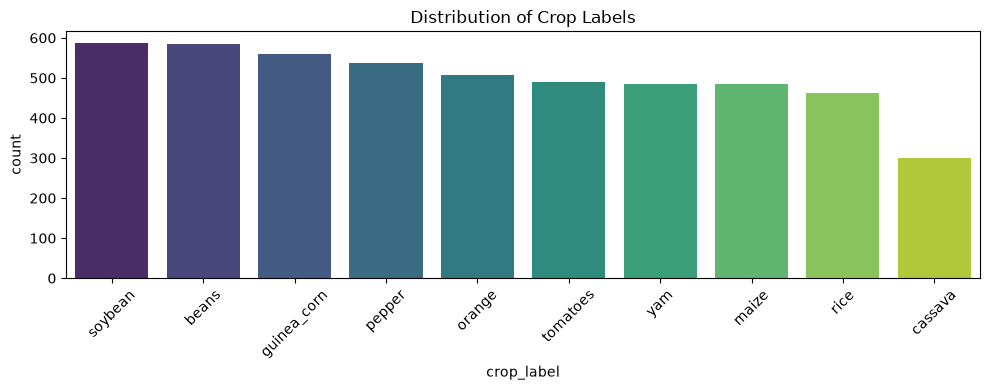

In [8]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df,
    x=target_col,
    order=df[target_col].value_counts().index,
    palette="viridis",
)
plt.title("Distribution of Crop Labels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Looking at Feature Distributions

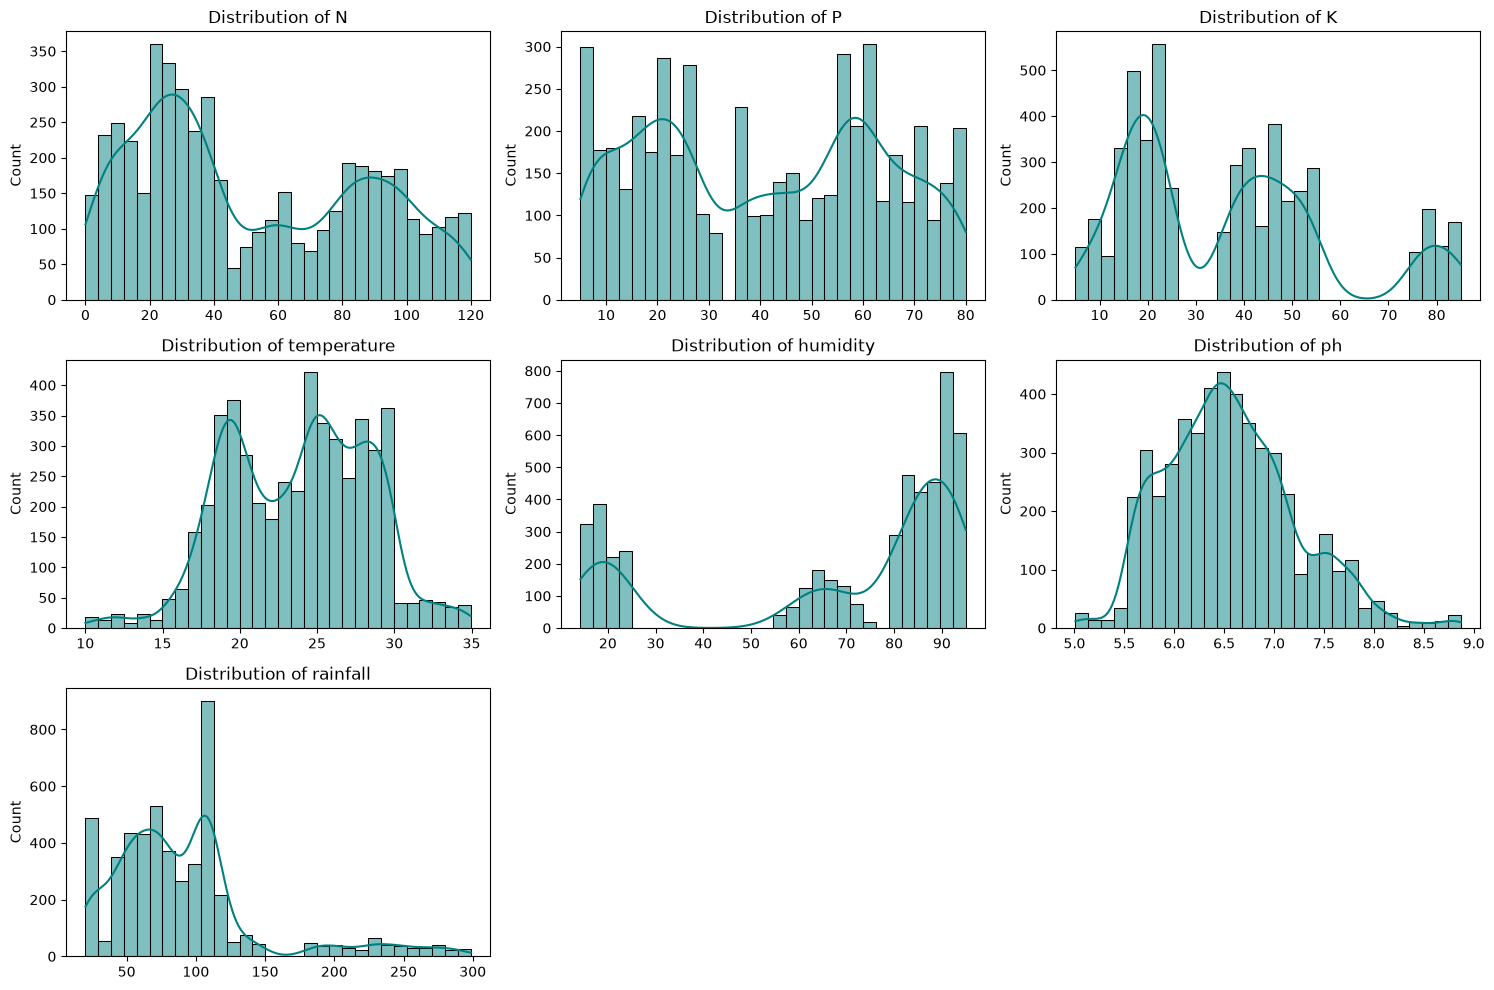

In [9]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="teal")
    plt.title(f"Distribution of {col}")
    plt.xlabel("")
plt.tight_layout()
plt.show()

Finding Outliers by looking at feature distribution for all labels

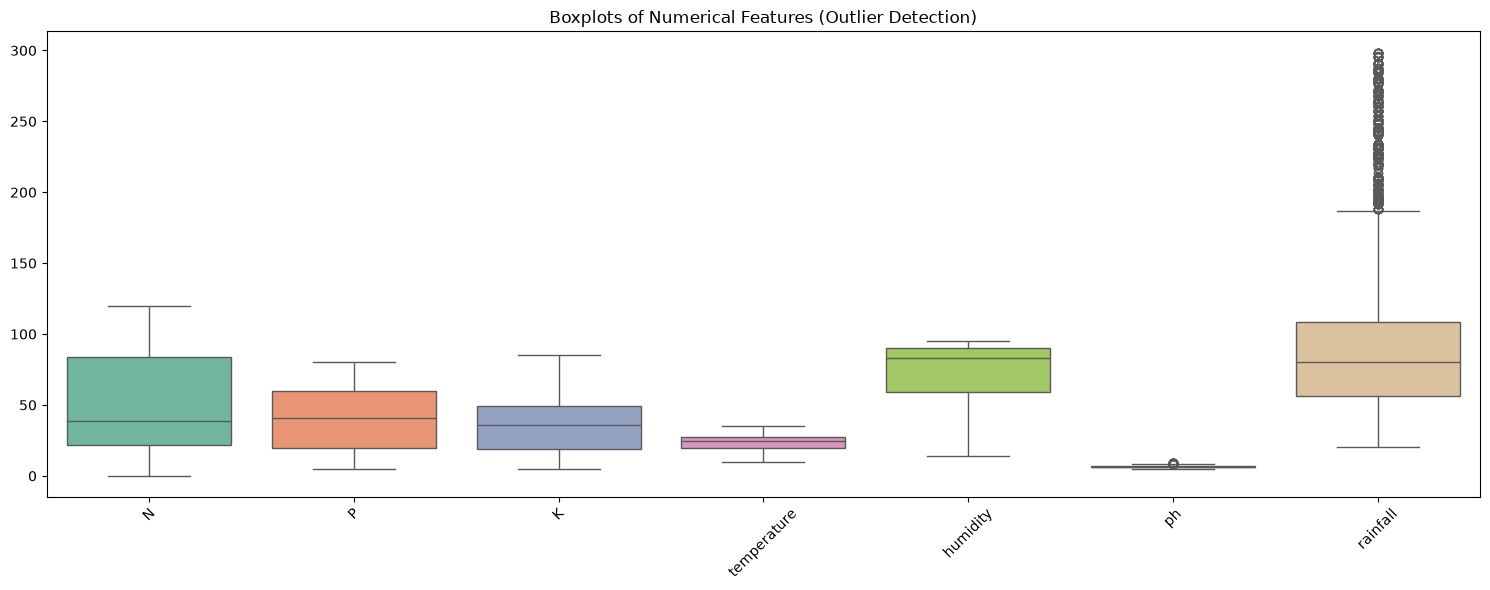

In [10]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[num_cols], palette="Set2")
plt.title("Boxplots of Numerical Features (Outlier Detection)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let's look at the feature distribution for each label



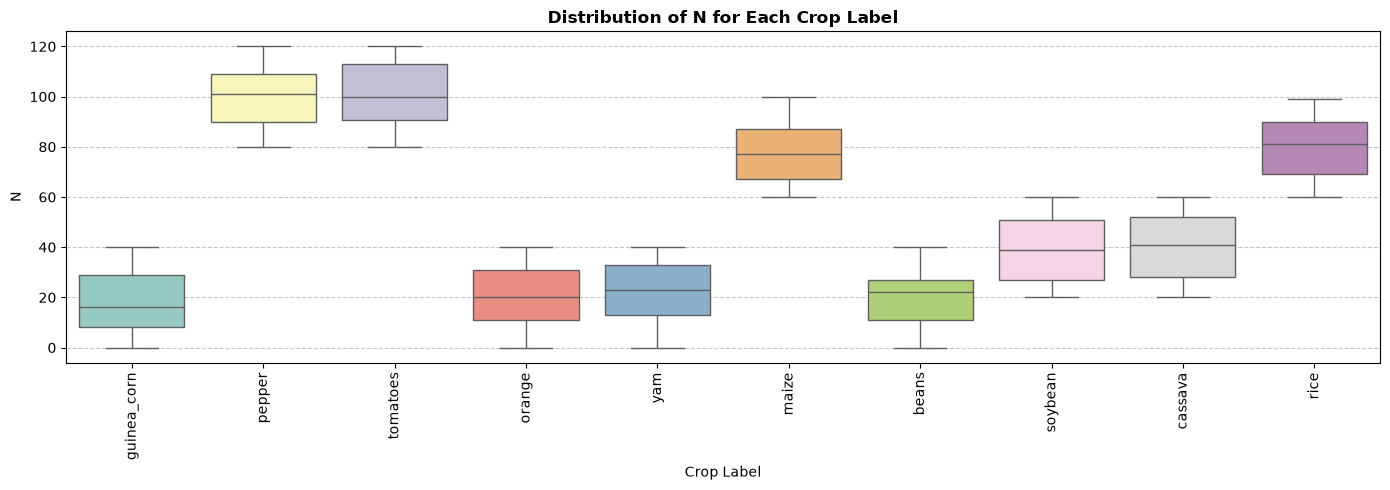

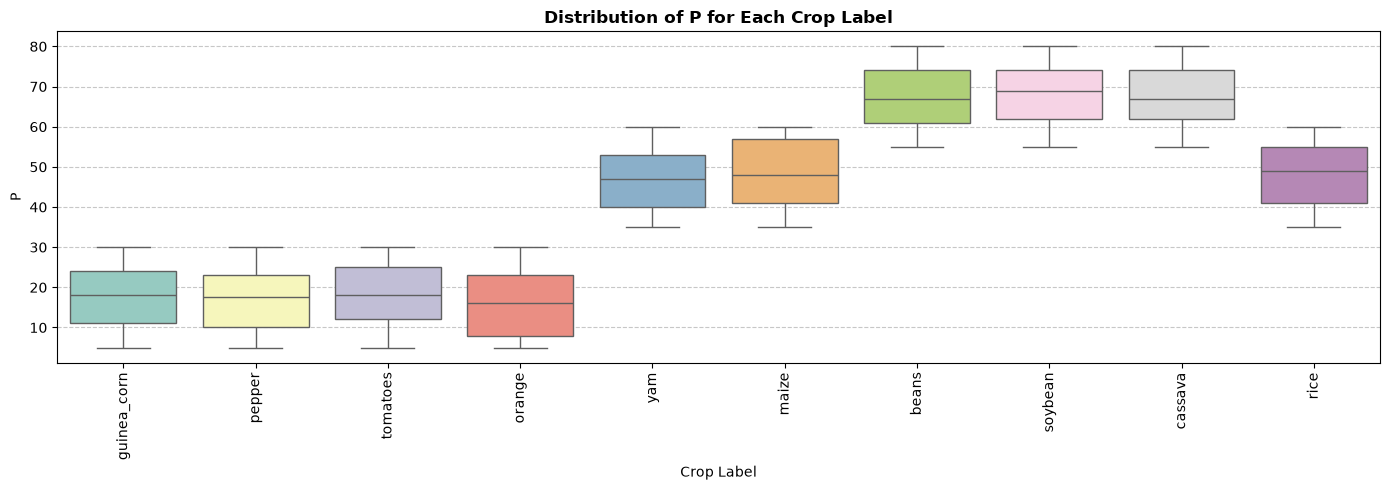

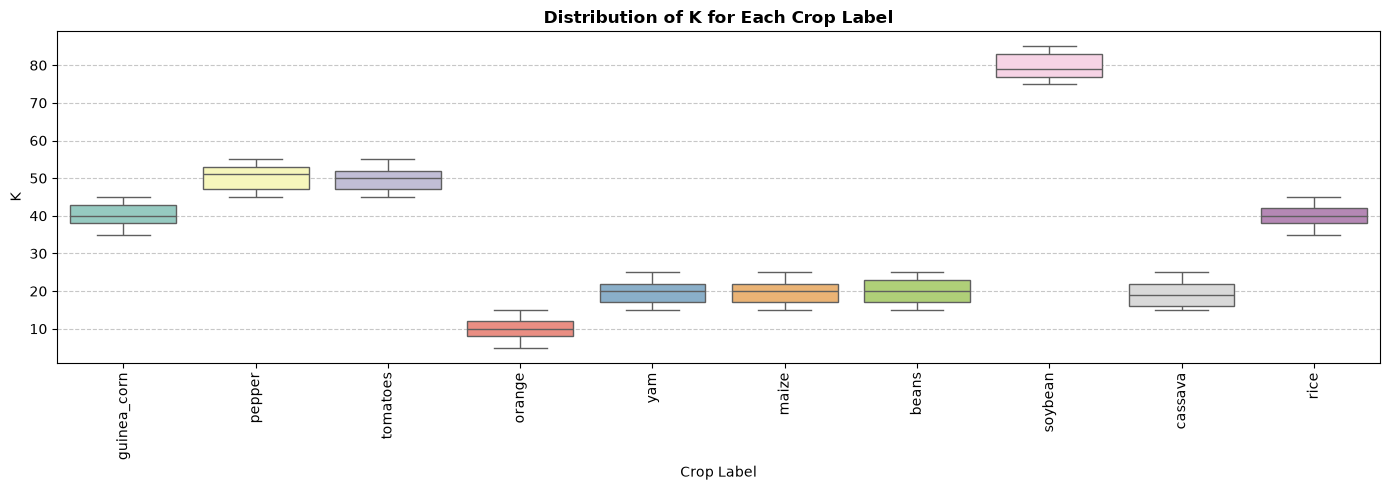

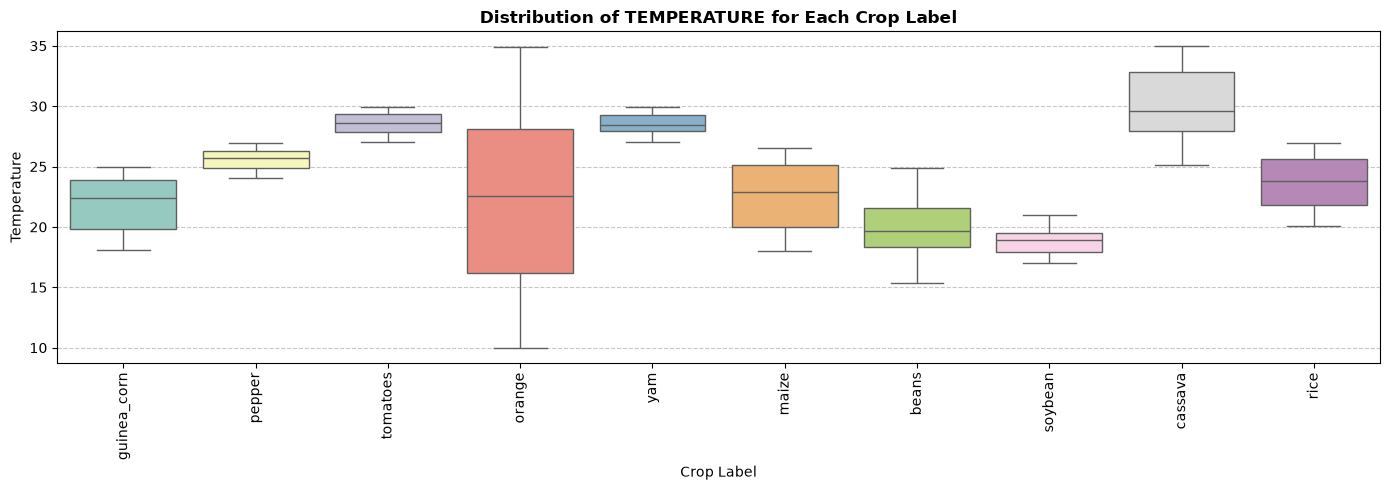

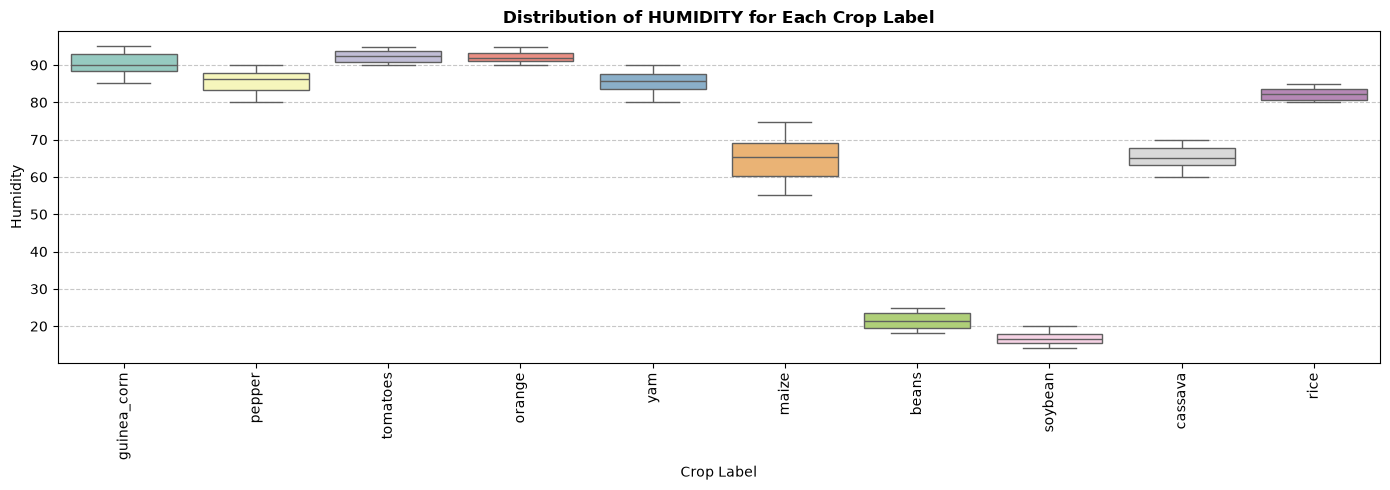

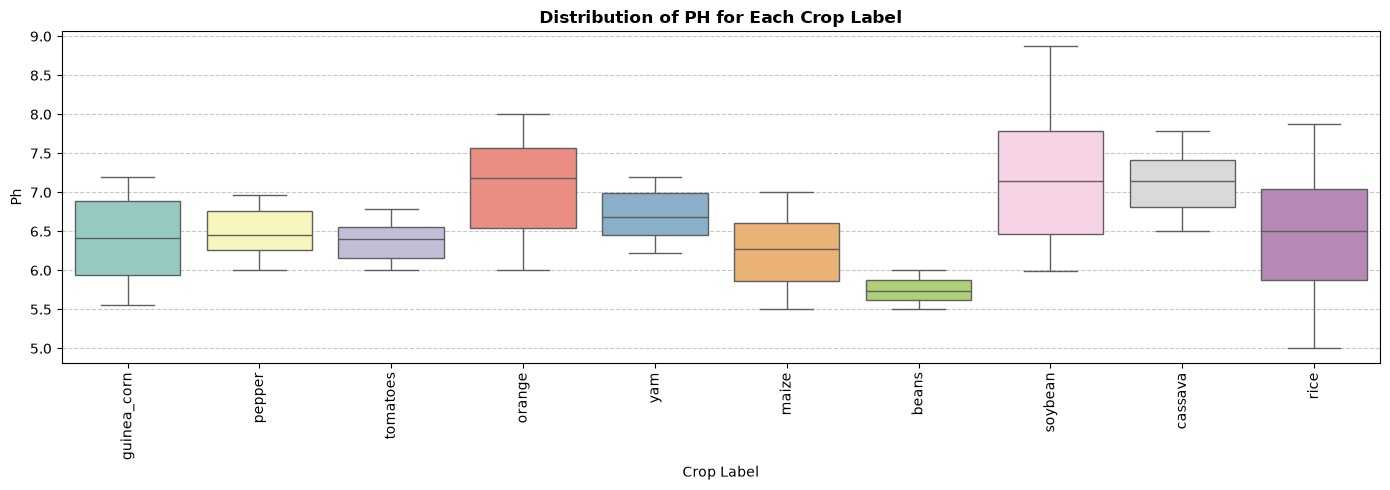

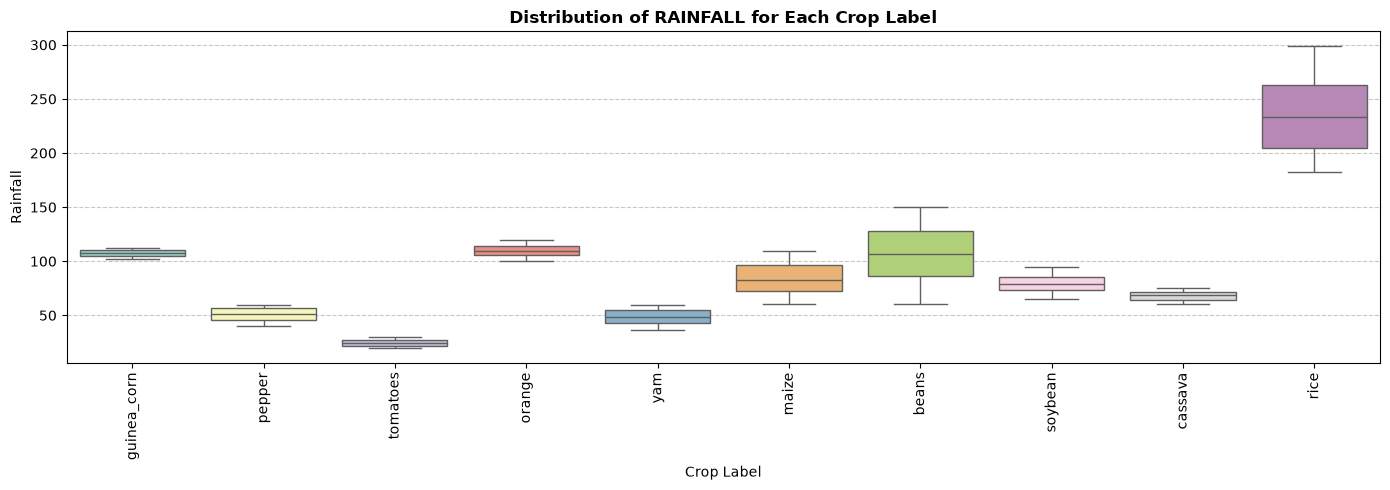

In [13]:
for col in num_cols:
  plt.figure(figsize=(14, 5))
  sns.boxplot(data=df, x=target_col, y=col, palette="Set3")
  plt.title(
      f"Distribution of {col.upper()} for Each Crop Label",
      fontsize=12,
      fontweight="bold",
  )
  plt.xlabel("Crop Label", fontsize=10)
  plt.ylabel(col.capitalize(), fontsize=10)
  plt.xticks(rotation=90)
  plt.grid(axis="y", linestyle="--", alpha=0.7)
  plt.tight_layout()
  plt.show()

Checking Feature Correlations

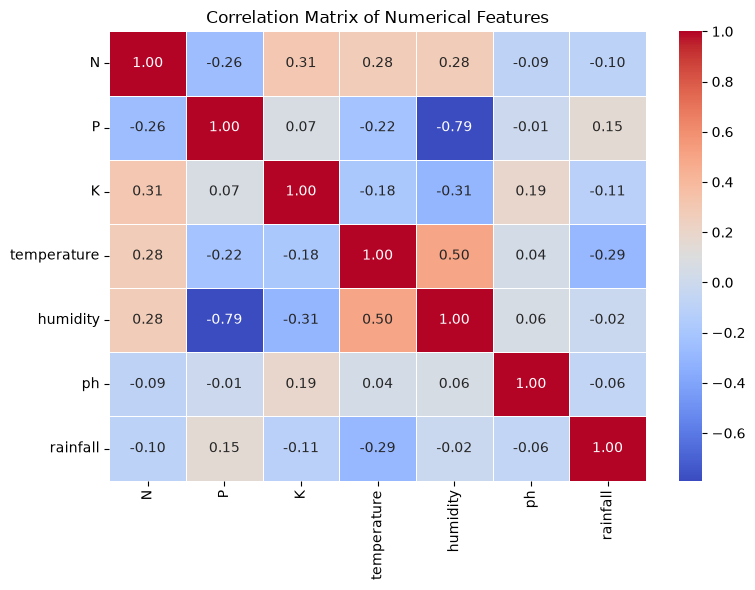

In [11]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Data Preprocessing and Feature Engineering

These features are not necessary, I was just testing if it will affect the model result

In [14]:
def engineer_features(data):
  df_fe = data.copy()
  if all(col in df_fe.columns for col in ["N", "P", "K"]):
    df_fe["total_npk"] = df_fe["N"] + df_fe["P"] + df_fe["K"]
    df_fe["npk_ratio"] = df_fe["N"] / (df_fe["P"] + df_fe["K"] + 1e-5)
  if "temperature" in df_fe.columns and "humidity" in df_fe.columns:
    df_fe["temp_humidity_interaction"] = (
        df_fe["temperature"] * df_fe["humidity"]
    )
  return df_fe

X = engineer_features(X)

Update numerical columns list after feature engineering

In [15]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['N',
 'P',
 'K',
 'temperature',
 'humidity',
 'ph',
 'rainfall',
 'total_npk',
 'npk_ratio',
 'temp_humidity_interaction']

Seperate the numerical and categorical columns, I did this here instead of earlier because I tried to combine some features

In [18]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Updated Numerical features: {num_cols}")
print(f"Categorical features: {cat_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Updated Numerical features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'total_npk', 'npk_ratio', 'temp_humidity_interaction']
Categorical features: ['soil']


Preprocessing Pipeline

In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

### Model Training

Random Forest Pipeline

In [21]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(n_estimators=100, random_state=42),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['beans','cassava','guinea_corn',...,'soybean','tomatoes','yam']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['N','P','K',...,'total_npk','npk_ratio','temp_humidity_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

In [22]:
y_pred_rf = rf_pipeline.predict(X_test)
print(
    "Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf) * 100, "%"
)

Random Forest Accuracy: 100.0 %


XGBoost Pipeline 

In [23]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                random_state=42,
                eval_metric="mlogloss",
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['N','P','K',...,'total_npk','npk_ratio','temp_humidity_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [24]:
y_pred_xgb_enc = xgb_pipeline.predict(X_test)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_enc)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb) * 100, "%")

XGBoost Accuracy: 100.0 %


### Evaluation


XGBoost Classification
              precision    recall  f1-score   support

       beans       1.00      1.00      1.00       117
     cassava       1.00      1.00      1.00        60
 guinea_corn       1.00      1.00      1.00       112
       maize       1.00      1.00      1.00        97
      orange       1.00      1.00      1.00       101
      pepper       1.00      1.00      1.00       108
        rice       1.00      1.00      1.00        93
     soybean       1.00      1.00      1.00       117
    tomatoes       1.00      1.00      1.00        98
         yam       1.00      1.00      1.00        97

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



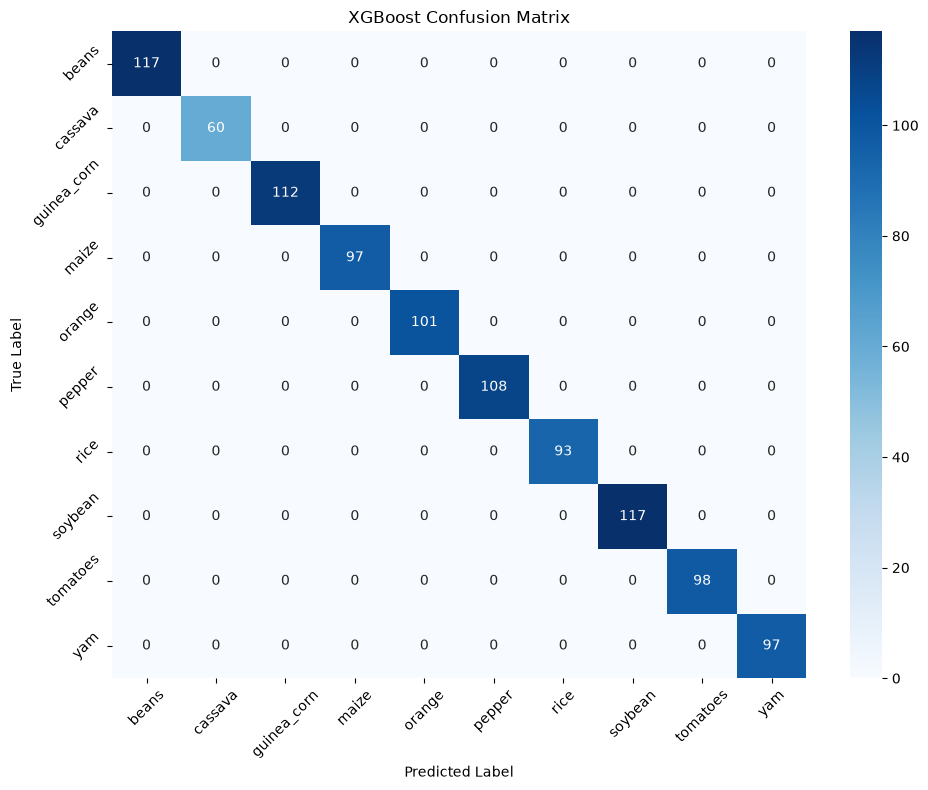

In [25]:
print("\nXGBoost Classification")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_xgb, labels=label_encoder.classes_)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()